In [1]:
import pandas as pd

# 1. โหลดไฟล์ทั้ง 2 ชุด
df_email1 = pd.read_excel('C:/Users/66982/OneDrive/Desktop/BOTNOI_AutoQC/NEW_QC_email1_ratio.xlsx')
df_email2 = pd.read_excel('C:/Users/66982/OneDrive/Desktop/BOTNOI_AutoQC/NEW_QC_email2_ratio.xlsx')

# mapping ชื่อ
unique_names1 = df_email1['user_id'].unique()
name_mapping1 = {name: f"u{i}" for i, name in enumerate(unique_names1, start=1)}
df_email1['new_user_id'] = df_email1['user_id'].map(name_mapping1)

unique_names2 = df_email2['uname'].unique()
name_mapping2 = {name: f"u{i}" for i, name in enumerate(unique_names2, start=1)}
df_email2['user_id'] = df_email2['uname'].map(name_mapping2)

# 2. ปรับชื่อคอลัมน์ให้เป็นมาตรฐานเดียวกัน
mapping_email1 = {
    'audio': 'url', 
    'new_user_id': 'speaker',
    'text': 'text'
}

mapping_email2 = {
    'audiourl': 'url',
    'user_id': 'speaker',
    'text': 'text'
}

# ทำการเปลี่ยนชื่อ (เฉพาะคอลัมน์ที่มีอยู่จริง)
df_email1 = df_email1.rename(columns=mapping_email1)
df_email2 = df_email2.rename(columns=mapping_email2)

# เพิ่มเผื่อใช้ groupby
df_email1['source'] = 'email1'
df_email2['source'] = 'email2'

# สร้าง Unique Index ใหม่ (เช่น e1_0, e2_0) เพื่อไม่ให้ทับกัน
df_email1['unique_id'] = 'e1_' + df_email1['audio_index'].astype(str)
df_email2['unique_id'] = 'e2_' + df_email2['audio_index'].astype(str)


# 3. เลือกเฉพาะคอลัมน์ที่จำเป็นต้องใช้เหมือนกันทั้งสองชุด
cols_to_keep = ['url', 'text', 'speaker', 'unique_id', 'ratio', 'source']
df_combined = pd.concat([df_email1[cols_to_keep], df_email2[cols_to_keep]], ignore_index=True)

print(f"✅ รวมข้อมูลเสร็จสิ้น! ทั้งหมด {len(df_combined)} แถว")

✅ รวมข้อมูลเสร็จสิ้น! ทั้งหมด 22084 แถว


In [ ]:
import IPython.display as ipd
import requests
import io
import time
from pydub import AudioSegment
import static_ffmpeg
static_ffmpeg.add_paths()

test_threshold = 1
df_test = df_combined[df_combined['ratio'] <= test_threshold].copy()
# เรียงลำดับตาม ratio จากน้อยไปมาก
df_test = df_test.sort_values('ratio', ascending=True)

print(f"✅ รวมข้อมูลสำเร็จ {len(df_combined)} แถว | พบไฟล์ Ratio >= {test_threshold} ทั้งหมด {len(df_test)} แถว")
print("-" * 50)

headers = {'User-Agent': 'Mozilla/5.0'}

# 5. Loop ตรวจสอบ
for index, row in df_test.iterrows():
    audio_url = row['url'] 
    # คราวนี้ unique_id จะไม่หายแล้วครับ!
    print(f"🔍 [ID: {row['unique_id']}] | Ratio: {row['ratio']:.2f}")
    print(f"📝 Text: {row['text']}")
    
    success = False
    try:
        r = requests.get(audio_url, headers=headers, timeout=15)
        if r.status_code == 200 and b'<Error>' not in r.content:
            audio = AudioSegment.from_file(io.BytesIO(r.content))
            wav_io = io.BytesIO()
            audio.export(wav_io, format="wav")
            display(ipd.Audio(wav_io.getvalue()))
            success = True
        else:
            print(f"❌ โหลดไม่ได้ (Status: {r.status_code})")
    except Exception as e:
        print(f"❌ Error: {e}")
            
    print("-" * 30)

In [13]:
import pandas as pd
from scipy import stats

# 1. กำหนดค่า Ratio ที่เราต้องการเช็ก
test_ratios = [20, 10, 8, 6, 0.5]

print(f"📊 ผลการคำนวณตำแหน่ง Percentile จากค่า Ratio ที่กำหนด")
print("="*60)

# 2. คำนวณแบบภาพรวม
print(f"จากข้อมูลทั้งหมด {len(df_combined)} ไฟล์")
for r in test_ratios:
    # คำนวณว่า r อยู่ที่ Percentile เท่าไหร่ของทั้งหมด
    p_global = stats.percentileofscore(df_combined['ratio'], r)
    if r > 5:
        print(f"   • Ratio >= {r:2} | อยู่ที่ตำแหน่ง Percentile ที่: {p_global:.2f}")
    else:
        print("-" * 60)
        print(f"   • Ratio <= {r:2} | อยู่ที่ตำแหน่ง Percentile ที่: {p_global:.2f}")



📊 ผลการคำนวณตำแหน่ง Percentile จากค่า Ratio ที่กำหนด
จากข้อมูลทั้งหมด 22084 ไฟล์
   • Ratio >= 20 | อยู่ที่ตำแหน่ง Percentile ที่: 99.91
   • Ratio >= 10 | อยู่ที่ตำแหน่ง Percentile ที่: 99.84
   • Ratio >=  8 | อยู่ที่ตำแหน่ง Percentile ที่: 99.82
   • Ratio >=  6 | อยู่ที่ตำแหน่ง Percentile ที่: 99.75
------------------------------------------------------------
   • Ratio <= 0.5 | อยู่ที่ตำแหน่ง Percentile ที่: 0.12


# Cutting Outlier

In [15]:
import pandas as pd
import os


# 1. รายชื่อไฟล์และชื่อคอลัมน์ที่ต้องการ Map ของแต่ละชุด
file_configs = [
    {
        'input_path': 'C:/Users/66982/OneDrive/Desktop/BOTNOI_AutoQC/NEW_QC_email1_ratio.xlsx',
        'output_name': 'new_Email1_Cleaned.xlsx',
        'mapping': {'audio': 'audio_url', 'user_id': 'speaker', 'text': 'text'},
        'tag': 'Email 1'
    },
    {
        'input_path': 'C:/Users/66982/OneDrive/Desktop/BOTNOI_AutoQC/NEW_QC_email2_ratio.xlsx',
        'output_name': 'new_Email2_Cleaned.xlsx',
        'mapping': {'audiourl': 'audio_url', 'uname': 'speaker', 'text': 'text'},
        'tag': 'Email 2'
    }
]

# 2. Cleaning Process
print("🚀 เริ่มต้นกระบวนการ Clean ข้อมูล...")
print("-" * 50)

for config in file_configs:
    # โหลดไฟล์
    df = pd.read_excel(config['input_path'])
    ori_count = len(df)
    
    # เปลี่ยนชื่อคอลัมน์ตาม Mapping ที่ตั้งไว้
    df = df.rename(columns=config['mapping'])
    
    # --- 🛠️ ขั้นตอนการกรองข้อมูล (Filtering) ---
    
    # 1. ตัดแถวที่ text เป็น NaN
    df_cleaned = df.dropna(subset=['text']).copy()
    nan_removed = ori_count - len(df_cleaned)
    
    # 2. ตัด Outlier 
    df_final = df_cleaned[(df_cleaned['ratio'] < 7.5) & (df_cleaned['ratio'] > 0.5)].copy()
    outlier_removed = len(df_cleaned) - len(df_final)
    
    # --- 💾 ส่งออกไฟล์ ---
    df_final.to_excel(config['output_name'], index=False)
    
    print(f"✅ {config['tag']} สำเร็จ!")
    print(f"   • จำนวนเริ่มต้น: {ori_count} แถว")
    print(f"   • ตัด Text NaN ออก: {nan_removed} แถว")
    print(f"   • ตัด Outlier (Ratio >= 7.5, Ratio <= 0.5) ออก: {outlier_removed} แถว")
    print(f"   • คงเหลือไฟล์ดี: {len(df_final)} แถว")
    print(f"   • บันทึกไฟล์ไปที่: {config['output_name']}")
    print("-" * 50)

print("✨ ทำความสะอาดข้อมูลเสร็จสมบูรณ์ทั้ง 2 ชุด")

🚀 เริ่มต้นกระบวนการ Clean ข้อมูล...
--------------------------------------------------
✅ Email 1 สำเร็จ!
   • จำนวนเริ่มต้น: 7071 แถว
   • ตัด Text NaN ออก: 27 แถว
   • ตัด Outlier (Ratio >= 7.5, Ratio <= 0.5) ออก: 33 แถว
   • คงเหลือไฟล์ดี: 7011 แถว
   • บันทึกไฟล์ไปที่: new_Email1_Cleaned.xlsx
--------------------------------------------------
✅ Email 2 สำเร็จ!
   • จำนวนเริ่มต้น: 15013 แถว
   • ตัด Text NaN ออก: 0 แถว
   • ตัด Outlier (Ratio >= 7.5, Ratio <= 0.5) ออก: 9 แถว
   • คงเหลือไฟล์ดี: 15004 แถว
   • บันทึกไฟล์ไปที่: new_Email2_Cleaned.xlsx
--------------------------------------------------
✨ ทำความสะอาดข้อมูลเสร็จสมบูรณ์ทั้ง 2 ชุด


# Percentile Email1 ใหม่

--- รายงานการเคลียร์ข้อมูล ---
ลบแถวที่คอลัมน์ 'token' เป็นค่าว่างไปทั้งหมด: 0 แถว
คงเหลือข้อมูลทั้งหมด: 7011 แถว
---------------------------


C:\Users\66982\AppData\Local\Temp\ipykernel_27620\17980445.py:86: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_final, x='ratio', y=speaker_col, ax=ax2, palette='Set3', fliersize=4)


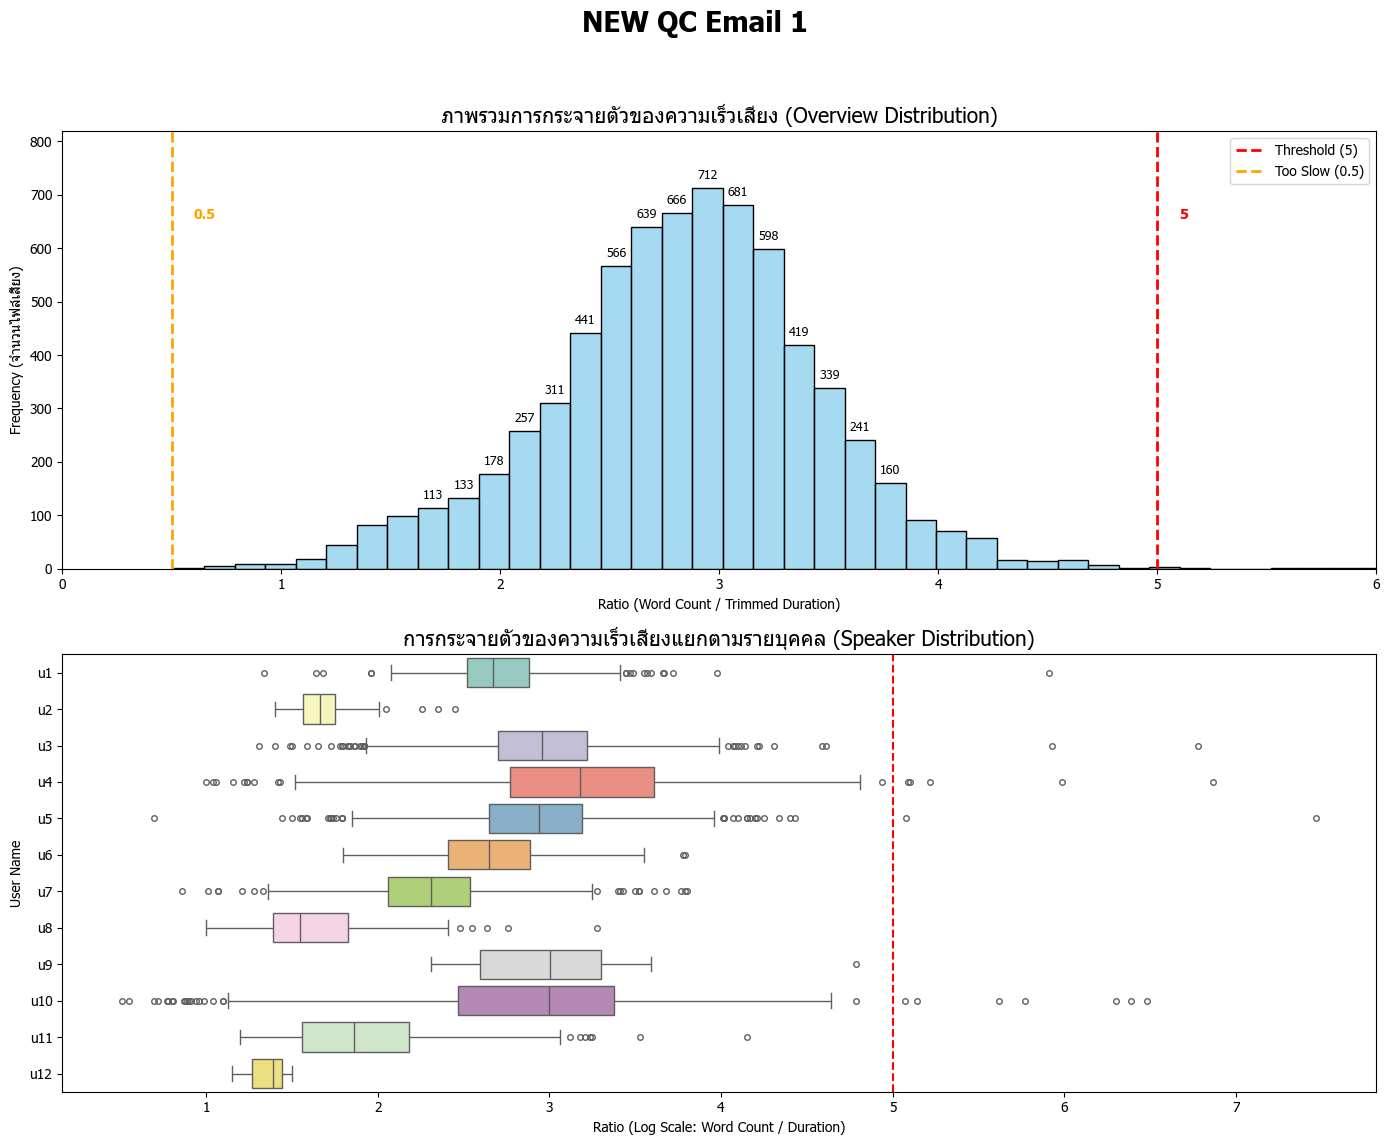

In [104]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. โหลดข้อมูล
file_path = 'C:/Users/66982/OneDrive/Desktop/BOTNOI_AutoQC/NewAutoQC-pythainlp/new_Email1_Cleaned.xlsx'
df_final = pd.read_excel(file_path)

# 1. หา "รายชื่อที่ไม่ซ้ำกันเลย" (Unique Names) ออกมาก่อน
unique_names = df_final['speaker'].unique()

# 2. สร้างคู่มือจับคู่ชื่อเก่า -> รหัส u ใหม่ 
# (เช่น {'Alice': 'u1', 'Bob': 'u2', ...})
name_mapping = {name: f"u{i}" for i, name in enumerate(unique_names, start=1)}

# 3. เอาคู่มือนี้ไป "แปลงค่า" (Map) ใส่คอลัมน์เดิมในตาราง
df_final['user_id'] = df_final['speaker'].map(name_mapping)



# --- ตรวจสอบและลบแถวที่ token เป็น null ---
# นับจำนวนแถวก่อนลบ
initial_rows = len(df_final)

# ลบแถวที่คอลัมน์ 'token' เป็นค่าว่าง (NaN หรือ Null)
df_final = df_final.dropna(subset=['tokens'])

# คำนวณจำนวนแถวที่ถูกลบไป
deleted_rows = initial_rows - len(df_final)
print(f"--- รายงานการเคลียร์ข้อมูล ---")
print(f"ลบแถวที่คอลัมน์ 'token' เป็นค่าว่างไปทั้งหมด: {deleted_rows} แถว")
print(f"คงเหลือข้อมูลทั้งหมด: {len(df_final)} แถว")
print(f"---------------------------")
# --------------------------------------------------------


# --- ฟอนต์ภาษาไทย ---
plt.rcParams['font.family'] = 'Tahoma' 
plt.rcParams['axes.unicode_minus'] = False # ป้องกันเครื่องหมายลบเพี้ยน

# สร้างพื้นที่แสดงผล 2 กราฟ (บน-ล่าง)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12))
fig.suptitle('NEW QC Email 1', fontsize=20, fontweight='bold')

# -------------------------------------------------------
# กราฟที่ 1: Distribution ภาพรวม 
# -------------------------------------------------------
df_plot = df_final[(df_final['ratio'] >= 0) & (df_final['ratio'] <= 10)]

# ใช้ df_plot แทน df_final ในการวาดกราฟแรก
sns.histplot(df_plot['ratio'], bins=50, color='skyblue', ax=ax1, edgecolor='black', stat='count')
# --- ใส่ตัวเลขกำกับบนแท่ง (เพิ่มต่อจาก sns.histplot) ---
for p in ax1.patches:
    height = p.get_height()
    if height > 100:  # เลือกแสดงเฉพาะแท่งที่มีจำนวนไฟล์ > 100 ไฟล์ เพื่อไม่ให้รกเกินไป
        ax1.annotate(f'{int(height)}', 
                     (p.get_x() + p.get_width() / 2., height), 
                     ha = 'center', va = 'center', 
                     xytext = (0, 9), 
                     textcoords = 'offset points',
                     fontsize=9, color='black')

# ปรับเพดานแกน Y ให้สูงขึ้นนิดหน่อยเพื่อให้มีที่ว่างวางตัวเลข
ax1.set_ylim(0, max([p.get_height() for p in ax1.patches]) * 1.15)

threshold_fast = 5
threshold_slow = 0.5
ax1.axvline(5, color='red', linestyle='--', linewidth=2, label='Threshold (5)')
ax1.text(threshold_fast + 0.1, ax1.get_ylim()[1]*0.8, f'{threshold_fast}', color='red', fontweight='bold')
ax1.axvline(0.5, color='orange', linestyle='--', linewidth=2, label='Too Slow (0.5)')
ax1.text(threshold_slow + 0.1, ax1.get_ylim()[1]*0.8, f'{threshold_slow}', color='orange', fontweight='bold')

ax1.set_xlim(0, 6)
ax1.set_title('ภาพรวมการกระจายตัวของความเร็วเสียง (Overview Distribution)', fontsize=15)
ax1.set_xlabel('Ratio (Word Count / Trimmed Duration)')
ax1.set_ylabel('Frequency (จำนวนไฟล์เสียง)')
ax1.legend()

# -------------------------------------------------------
# กราฟที่ 2: Distribution รายคน (Boxplot)
# -------------------------------------------------------
speaker_col = df_final.columns[16] 

# พล็อตทุกคนที่มีชื่อปรากฏ
sns.boxplot(data=df_final, x='ratio', y=speaker_col, ax=ax2, palette='Set3', fliersize=4)

ax2.axvline(5, color='red', linestyle='--', linewidth=1.5)

ax2.set_title('การกระจายตัวของความเร็วเสียงแยกตามรายบุคคล (Speaker Distribution)', fontsize=15)
ax2.set_ylabel('User Name')
ax2.set_xlabel('Ratio (Log Scale: Word Count / Duration)')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])

plt.show()


In [72]:
df_final.columns

Index(['audio_url', 'speaker', 'test', 'id', 'text', 'audio_index',
       'word_count', 'tokens', 'trim_duration', 'ratio', 'user_id'],
      dtype='str')

## Individual Percentile cutofff

👤 Analysis for: u11
✅ จำนวนไฟล์ทั้งหมดของคนนี้: 200 ไฟล์
📊 ค่าเฉลี่ยความเร็วปกติของเขา (Median): 1.86
🚩 จุดตัดฝั่งเร็ว (P99.6): 3.66
🚩 จุดตัดฝั่งช้า (P0.1): 1.20


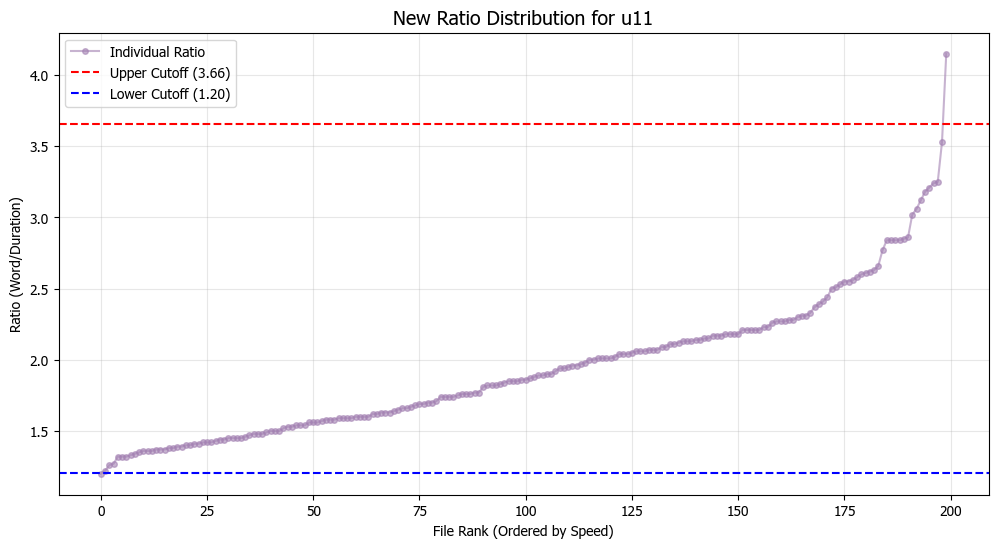

In [105]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pandas as pd

# 1. หา "รายชื่อที่ไม่ซ้ำกันเลย" (Unique Names) ออกมาก่อน
unique_names = df_final['speaker'].unique()

# 2. สร้างคู่มือจับคู่ชื่อเก่า -> รหัส u ใหม่ 
name_mapping = {name: f"u{i}" for i, name in enumerate(unique_names, start=1)}

# 3. เอาคู่มือนี้ไป "แปลงค่า" (Map) ใส่คอลัมน์เดิมในตาราง
df_final['user_id'] = df_final['speaker'].map(name_mapping)


# 1. ดึงข้อมูลเฉพาะ User
speaker_col = df_final.columns[16]
target_user = 'u11'
user_data = df_final[(df_final[speaker_col] == target_user) & (df_final['word_count'] > 0)].copy()

# 2. เรียงลำดับข้อมูลตาม Ratio จากน้อยไปมาก
user_data = user_data.sort_values('ratio')

## --- ปรับเกณฑ์ Percentile ทั้งสองฝั่ง ---
# ฝั่งเร็วผิดปกติ (Upper)
upper_p = 0.996
upper_cutoff = user_data['ratio'].quantile(upper_p)

# ฝั่งช้าผิดปกติ (Lower) - ลองดูที่ 0.5% ล่างสุด
lower_p = 0.001
lower_cutoff = user_data['ratio'].quantile(lower_p)

print(f"👤 Analysis for: {target_user}")
print(f"✅ จำนวนไฟล์ทั้งหมดของคนนี้: {len(user_data)} ไฟล์")
print(f"📊 ค่าเฉลี่ยความเร็วปกติของเขา (Median): {user_data['ratio'].median():.2f}")
print(f"🚩 จุดตัดฝั่งเร็ว (P{upper_p*100}): {upper_cutoff:.2f}")
print(f"🚩 จุดตัดฝั่งช้า (P{lower_p*100}): {lower_cutoff:.2f}")

# 4. พล็อตกราฟดูการ 'กระโดด' ทั้งบนและล่าง
plt.figure(figsize=(12, 6))
plt.plot(range(len(user_data)), user_data['ratio'], 'o-', color= "#A381B2", markersize=4, alpha=0.6, label='Individual Ratio')

# วาดเส้นจุดตัดทั้งสองฝั่ง
plt.axhline(upper_cutoff, color='red', linestyle='--', label=f'Upper Cutoff ({upper_cutoff:.2f})')
plt.axhline(lower_cutoff, color='blue', linestyle='--', label=f'Lower Cutoff ({lower_cutoff:.2f})')

plt.title(f'New Ratio Distribution for {target_user}', fontsize=14)
plt.ylabel('Ratio (Word/Duration)')

#plt.yscale('symlog', linthresh=6) 

# ปรับเลขแกน Y ให้เห็นชัดทั้งช่วงต่ำและสูง
#plt.yticks([0, lower_cutoff, 2, 3,100, 125, upper_cutoff])
#plt.gca().get_yaxis().set_major_formatter(ticker.ScalarFormatter())

plt.xlabel('File Rank (Ordered by Speed)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

##  Audit

In [66]:
import IPython.display as ipd
import os
import requests
import shutil
import io
from pydub import AudioSegment
import static_ffmpeg
static_ffmpeg.add_paths()

audit_temp_dir = 'audit_temp_samples'

# 1. ล้างโฟลเดอร์เก่า
if os.path.exists(audit_temp_dir):
    shutil.rmtree(audit_temp_dir)
os.makedirs(audit_temp_dir)

# 2. กรองข้อมูล Outlier
samples_to_audit = user_data[
    (user_data['ratio'] >= upper_cutoff) | 
    (user_data['ratio'] <= lower_cutoff)
].copy()

print(f"👤 ตรวจสอบ User: {target_user}")
print(f"🎧 ช่วงที่ตรวจสอบ: ต่ำกว่า {lower_cutoff:.2f} (🐢) และ สูงกว่า {upper_cutoff:.2f} (🚀)")
print(f"📦 จำนวนที่ต้อง Audit ทั้งหมด: {len(samples_to_audit)} ไฟล์")
print("-" * 50)

for index, row in samples_to_audit.iterrows():
    audio_url = row['audio_url']
    ext = os.path.splitext(audio_url)[1].split('?')[0] or '.m4a'
    local_filename = os.path.join(audit_temp_dir, f"audit_{index}{ext}")
    
    try:
        # 3. ดาวน์โหลดไฟล์ด้วยความระมัดระวัง
        response = requests.get(audio_url, timeout=15, stream=True)
        
        if response.status_code == 200:
            content = response.content
            
            # ตรวจสอบว่าไฟล์ไม่ใช่ไฟล์เปล่า (ต้องมีขนาด > 100 bytes)
            if len(content) < 100:
                print(f"⚠️ Index {index}: ไฟล์จาก URL มีขนาดเล็กเกินไป (อาจเป็น Link เสีย)")
                continue
                
            # บันทึกไฟล์ลงเครื่อง
            with open(local_filename, 'wb') as f:
                f.write(content)
            
            # 4. ใช้ pydub ประมวลผลจากข้อมูลที่โหลดมาโดยตรง
            # ลองโหลดจากไฟล์ที่เพิ่งเขียน
            audio = AudioSegment.from_file(local_filename)
            
            print(f"🔍 [Index: {index}] | Ratio: {row['ratio']:.2f}")
            print(f"📝 Text: {row['text']}")
            
            # แปลงเป็น WAV เพื่อเล่นบน Browser
            wav_io = io.BytesIO()
            audio.export(wav_io, format="wav")
            display(ipd.Audio(wav_io.getvalue()))
            
        else:
            print(f"❌ Index {index}: โหลดไม่ได้ StatusCode: {response.status_code}")

    except Exception as e:
        print(f"❌ Index {index} เกิดข้อผิดพลาด: {e}")
        
    print("-" * 30)

👤 ตรวจสอบ User: u11
🎧 ช่วงที่ตรวจสอบ: ต่ำกว่า 1.20 (🐢) และ สูงกว่า 3.48 (🚀)
📦 จำนวนที่ต้อง Audit ทั้งหมด: 3 ไฟล์
--------------------------------------------------
🔍 [Index: 6560] | Ratio: 1.20
📝 Text: ซี เฮช ยู เอส เอ เค อี แอท แอดมิน ดอท กอฟ ดอท เอยู


------------------------------
🔍 [Index: 5882] | Ratio: 3.53
📝 Text: เอสซีจี ดอท คอม


------------------------------
🔍 [Index: 5890] | Ratio: 4.15
📝 Text: บี เอ ซี เค อี เอ็น ดี แอท เดนท์ ดอท จุฬา ดอท เอซี ดอท ทีเอช


------------------------------


In [ ]:
import IPython.display as ipd
import os
import requests
import shutil
import io
from pydub import AudioSegment
import static_ffmpeg
static_ffmpeg.add_paths()

audit_temp_dir = 'audit_temp_samples'

# 1. ล้างโฟลเดอร์เก่า
if os.path.exists(audit_temp_dir):
    shutil.rmtree(audit_temp_dir)
os.makedirs(audit_temp_dir)

# 2. กรองข้อมูล Outlier
samples_to_audit = user_data[
    (user_data['ratio'] >= upper_cutoff) | 
    (user_data['ratio'] <= lower_cutoff)
].copy()

print(f"👤 ตรวจสอบ User: {target_user}")
print(f"🎧 ช่วงที่ตรวจสอบ: ต่ำกว่า {lower_cutoff:.2f} (🐢) และ สูงกว่า {upper_cutoff:.2f} (🚀)")
print(f"📦 จำนวนที่ต้อง Audit ทั้งหมด: {len(samples_to_audit)} ไฟล์")
print("-" * 50)

for index, row in samples_to_audit.iterrows():
    audio_url = row['audio_url']
    ext = os.path.splitext(audio_url)[1].split('?')[0] or '.m4a'
    local_filename = os.path.join(audit_temp_dir, f"audit_{index}{ext}")
    
    try:
        # 3. ดาวน์โหลดไฟล์ด้วยความระมัดระวัง
        response = requests.get(audio_url, timeout=15, stream=True)
        
        if response.status_code == 200:
            content = response.content
            
            # ตรวจสอบว่าไฟล์ไม่ใช่ไฟล์เปล่า (ต้องมีขนาด > 100 bytes)
            if len(content) < 100:
                print(f"⚠️ Index {index}: ไฟล์จาก URL มีขนาดเล็กเกินไป (อาจเป็น Link เสีย)")
                continue
                
            # บันทึกไฟล์ลงเครื่อง
            with open(local_filename, 'wb') as f:
                f.write(content)
            
            # 4. ใช้ pydub ประมวลผลจากข้อมูลที่โหลดมาโดยตรง
            # ลองโหลดจากไฟล์ที่เพิ่งเขียน
            audio = AudioSegment.from_file(local_filename)
            
            print(f"🔍 [Index: {index}] | Ratio: {row['ratio']:.2f}")
            print(f"📝 Text: {row['text']}")
            
            # แปลงเป็น WAV เพื่อเล่นบน Browser
            wav_io = io.BytesIO()
            audio.export(wav_io, format="wav")
            display(ipd.Audio(wav_io.getvalue()))
            
        else:
            print(f"❌ Index {index}: โหลดไม่ได้ StatusCode: {response.status_code}")

    except Exception as e:
        print(f"❌ Index {index} เกิดข้อผิดพลาด: {e}")
        
    print("-" * 30)

👤 ตรวจสอบ User: u11
🎧 ช่วงที่ตรวจสอบ: ต่ำกว่า 1.20 (🐢) และ สูงกว่า 3.48 (🚀)
📦 จำนวนที่ต้อง Audit ทั้งหมด: 3 ไฟล์
--------------------------------------------------
🔍 [Index: 6560] | Ratio: 1.20
📝 Text: ซี เฮช ยู เอส เอ เค อี แอท แอดมิน ดอท กอฟ ดอท เอยู


------------------------------
🔍 [Index: 5882] | Ratio: 3.53
📝 Text: เอสซีจี ดอท คอม


------------------------------
🔍 [Index: 5890] | Ratio: 4.15
📝 Text: บี เอ ซี เค อี เอ็น ดี แอท เดนท์ ดอท จุฬา ดอท เอซี ดอท ทีเอช


------------------------------


# Percentile Email2 ใหม่

--- รายงานการเคลียร์ข้อมูล ---
ลบแถวที่คอลัมน์ 'token' เป็นค่าว่างไปทั้งหมด: 0 แถว
คงเหลือข้อมูลทั้งหมด: 15004 แถว
---------------------------


C:\Users\66982\AppData\Local\Temp\ipykernel_27620\898367462.py:85: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_final, y='ratio', x=speaker_col, ax=ax2, palette='Set3', fliersize=4)


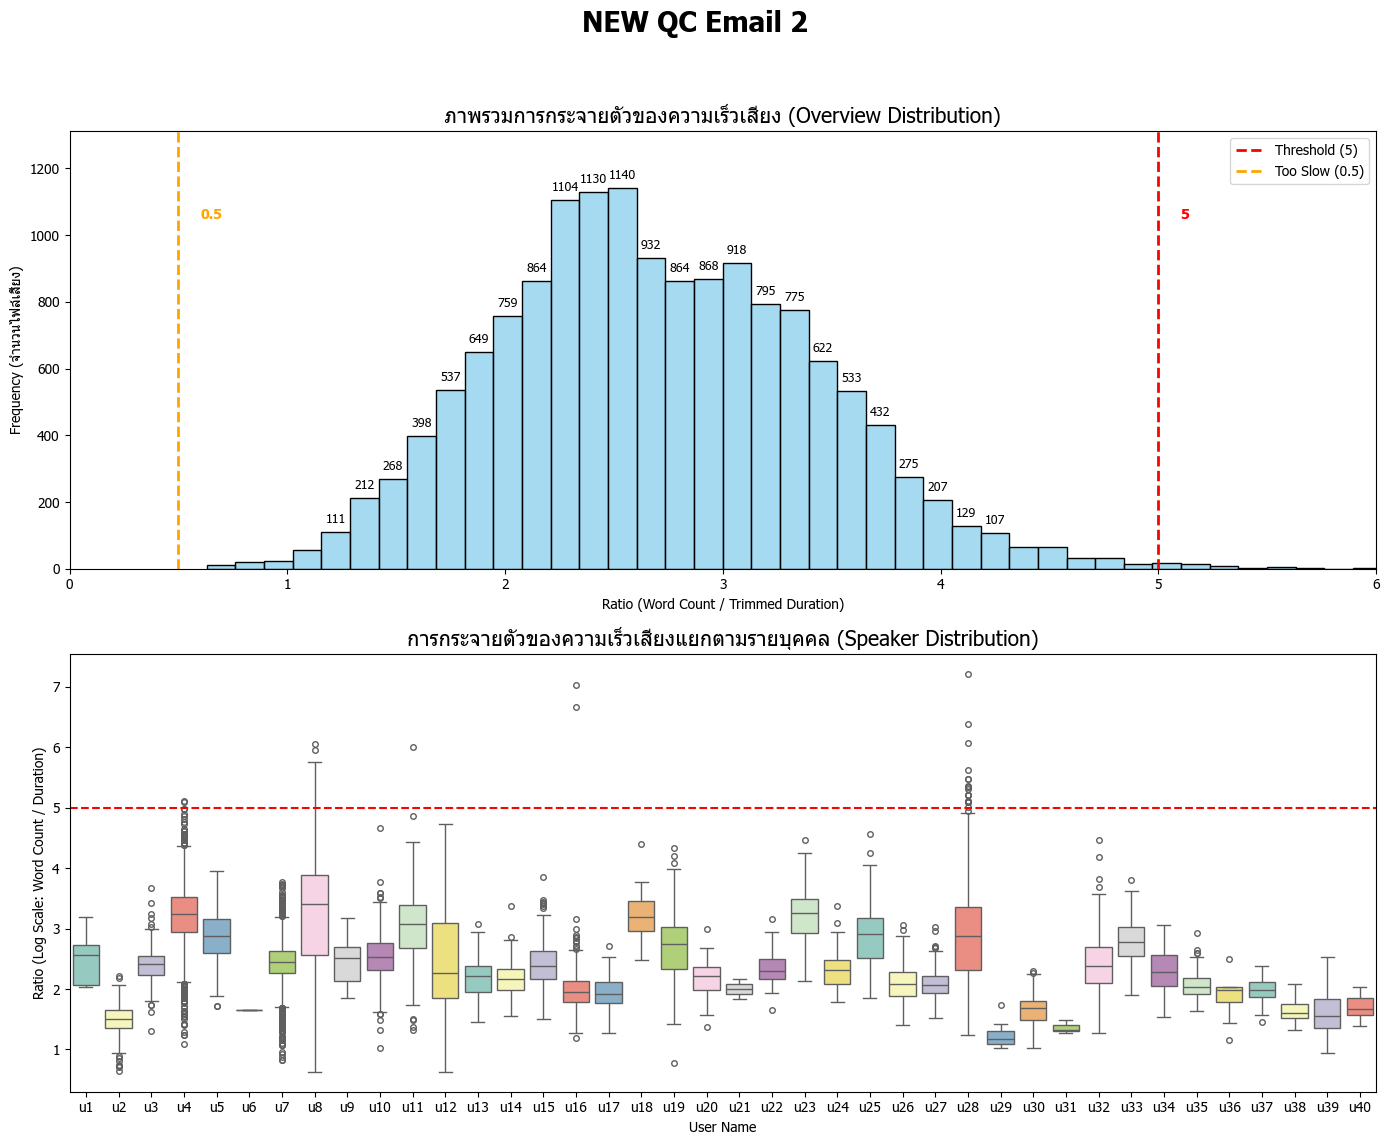

In [106]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. โหลดข้อมูล
file_path = 'C:/Users/66982/OneDrive/Desktop/BOTNOI_AutoQC/NewAutoQC-pythainlp/new_Email2_Cleaned.xlsx'
df_final = pd.read_excel(file_path)

# 1. หา "รายชื่อที่ไม่ซ้ำกันเลย" (Unique Names) ออกมาก่อน
unique_names = df_final['speaker'].unique()

# 2. สร้างคู่มือจับคู่ชื่อเก่า -> รหัส u ใหม่ 
name_mapping = {name: f"u{i}" for i, name in enumerate(unique_names, start=1)}

# 3. เอาคู่มือนี้ไป "แปลงค่า" (Map) ใส่คอลัมน์เดิมในตาราง
df_final['user_id'] = df_final['speaker'].map(name_mapping)



# --- ตรวจสอบและลบแถวที่ token เป็น null ---
# นับจำนวนแถวก่อนลบ
initial_rows = len(df_final)

# ลบแถวที่คอลัมน์ 'token' เป็นค่าว่าง (NaN หรือ Null)
df_final = df_final.dropna(subset=['tokens'])

# คำนวณจำนวนแถวที่ถูกลบไป
deleted_rows = initial_rows - len(df_final)
print(f"--- รายงานการเคลียร์ข้อมูล ---")
print(f"ลบแถวที่คอลัมน์ 'token' เป็นค่าว่างไปทั้งหมด: {deleted_rows} แถว")
print(f"คงเหลือข้อมูลทั้งหมด: {len(df_final)} แถว")
print(f"---------------------------")
# --------------------------------------------------------


# --- ฟอนต์ภาษาไทย ---
plt.rcParams['font.family'] = 'Tahoma' 
plt.rcParams['axes.unicode_minus'] = False # ป้องกันเครื่องหมายลบเพี้ยน

# สร้างพื้นที่แสดงผล 2 กราฟ (บน-ล่าง)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12))
fig.suptitle('NEW QC Email 2', fontsize=20, fontweight='bold')

# -------------------------------------------------------
# กราฟที่ 1: Distribution ภาพรวม 
# -------------------------------------------------------
df_plot = df_final[(df_final['ratio'] >= 0) & (df_final['ratio'] <= 10)]

# ใช้ df_plot แทน df_final ในการวาดกราฟแรก
sns.histplot(df_plot['ratio'], bins=50, color='skyblue', ax=ax1, edgecolor='black', stat='count')
# --- ใส่ตัวเลขกำกับบนแท่ง (เพิ่มต่อจาก sns.histplot) ---
for p in ax1.patches:
    height = p.get_height()
    if height > 100:  # เลือกแสดงเฉพาะแท่งที่มีจำนวนไฟล์ > 100 ไฟล์ เพื่อไม่ให้รกเกินไป
        ax1.annotate(f'{int(height)}', 
                     (p.get_x() + p.get_width() / 2., height), 
                     ha = 'center', va = 'center', 
                     xytext = (0, 9), 
                     textcoords = 'offset points',
                     fontsize=9, color='black')

# ปรับเพดานแกน Y ให้สูงขึ้นนิดหน่อยเพื่อให้มีที่ว่างวางตัวเลข
ax1.set_ylim(0, max([p.get_height() for p in ax1.patches]) * 1.15)

threshold_fast = 5
threshold_slow = 0.5
ax1.axvline(5, color='red', linestyle='--', linewidth=2, label='Threshold (5)')
ax1.text(threshold_fast + 0.1, ax1.get_ylim()[1]*0.8, f'{threshold_fast}', color='red', fontweight='bold')
ax1.axvline(0.5, color='orange', linestyle='--', linewidth=2, label='Too Slow (0.5)')
ax1.text(threshold_slow + 0.1, ax1.get_ylim()[1]*0.8, f'{threshold_slow}', color='orange', fontweight='bold')

ax1.set_xlim(0, 6)
ax1.set_title('ภาพรวมการกระจายตัวของความเร็วเสียง (Overview Distribution)', fontsize=15)
ax1.set_xlabel('Ratio (Word Count / Trimmed Duration)')
ax1.set_ylabel('Frequency (จำนวนไฟล์เสียง)')
ax1.legend()

# -------------------------------------------------------
# กราฟที่ 2: Distribution รายคน (Boxplot)
# -------------------------------------------------------
speaker_col = df_final.columns[10] 

# พล็อตทุกคนที่มีชื่อปรากฏ
sns.boxplot(data=df_final, y='ratio', x=speaker_col, ax=ax2, palette='Set3', fliersize=4)

ax2.axhline(5, color='red', linestyle='--', linewidth=1.5)

ax2.set_title('การกระจายตัวของความเร็วเสียงแยกตามรายบุคคล (Speaker Distribution)', fontsize=15)
ax2.set_xlabel('User Name')
ax2.set_ylabel('Ratio (Log Scale: Word Count / Duration)')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])

plt.show()


## Individual Percentile cutofff

👤 Analysis for: u40
✅ จำนวนไฟล์ทั้งหมดของคนนี้: 34 ไฟล์
📊 ค่าเฉลี่ยความเร็วปกติของเขา (Median): 1.67
🚩 จุดตัดฝั่งเร็ว (P99.5): 2.04
🚩 จุดตัดฝั่งช้า (P0.1): 1.39


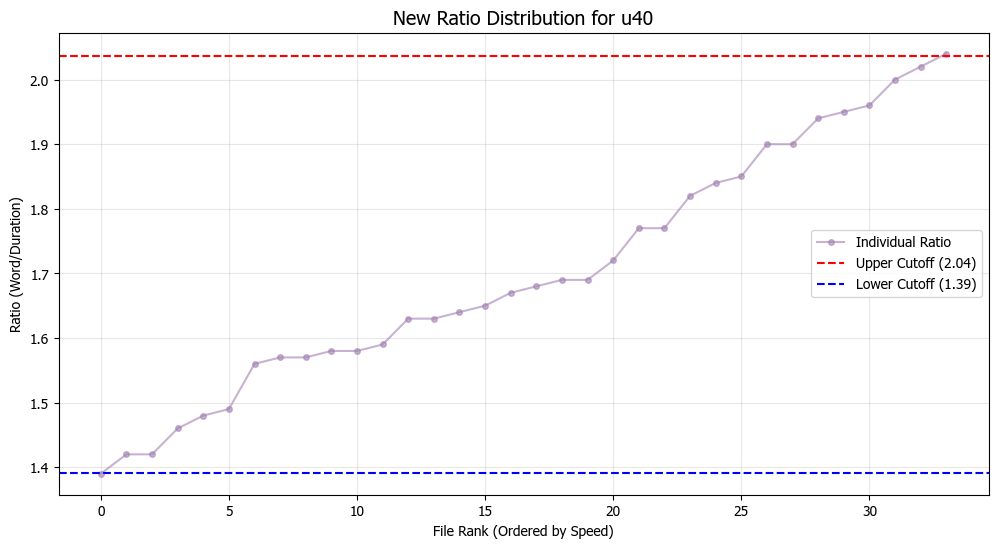

In [175]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pandas as pd

# 1. หา "รายชื่อที่ไม่ซ้ำกันเลย" (Unique Names) ออกมาก่อน
unique_names = df_final['speaker'].unique()

# 2. สร้างคู่มือจับคู่ชื่อเก่า -> รหัส u ใหม่ 
name_mapping = {name: f"u{i}" for i, name in enumerate(unique_names, start=1)}

# 3. เอาคู่มือนี้ไป "แปลงค่า" (Map) ใส่คอลัมน์เดิมในตาราง
df_final['user_id'] = df_final['speaker'].map(name_mapping)


# 1. ดึงข้อมูลเฉพาะ User
speaker_col = df_final.columns[10]
target_user = 'u40'
user_data = df_final[(df_final[speaker_col] == target_user) & (df_final['word_count'] > 0)].copy()

# 2. เรียงลำดับข้อมูลตาม Ratio จากน้อยไปมาก
user_data = user_data.sort_values('ratio')

## --- ปรับเกณฑ์ Percentile ทั้งสองฝั่ง ---
# ฝั่งเร็วผิดปกติ (Upper)
upper_p = 0.995
upper_cutoff = user_data['ratio'].quantile(upper_p)

# ฝั่งช้าผิดปกติ (Lower) - ลองดูที่ 0.5% ล่างสุด
lower_p = 0.001
lower_cutoff = user_data['ratio'].quantile(lower_p)

print(f"👤 Analysis for: {target_user}")
print(f"✅ จำนวนไฟล์ทั้งหมดของคนนี้: {len(user_data)} ไฟล์")
print(f"📊 ค่าเฉลี่ยความเร็วปกติของเขา (Median): {user_data['ratio'].median():.2f}")
print(f"🚩 จุดตัดฝั่งเร็ว (P{upper_p*100}): {upper_cutoff:.2f}")
print(f"🚩 จุดตัดฝั่งช้า (P{lower_p*100}): {lower_cutoff:.2f}")

# 4. พล็อตกราฟดูการ 'กระโดด' ทั้งบนและล่าง
plt.figure(figsize=(12, 6))
plt.plot(range(len(user_data)), user_data['ratio'], 'o-', color= "#A381B2", markersize=4, alpha=0.6, label='Individual Ratio')

# วาดเส้นจุดตัดทั้งสองฝั่ง
plt.axhline(upper_cutoff, color='red', linestyle='--', label=f'Upper Cutoff ({upper_cutoff:.2f})')
plt.axhline(lower_cutoff, color='blue', linestyle='--', label=f'Lower Cutoff ({lower_cutoff:.2f})')

plt.title(f'New Ratio Distribution for {target_user}', fontsize=14)
plt.ylabel('Ratio (Word/Duration)')

#plt.yscale('symlog', linthresh=6) 

# ปรับเลขแกน Y ให้เห็นชัดทั้งช่วงต่ำและสูง
#plt.yticks([0, lower_cutoff, 2, 3,100, 125, upper_cutoff])
#plt.gca().get_yaxis().set_major_formatter(ticker.ScalarFormatter())

plt.xlabel('File Rank (Ordered by Speed)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

##  Audit

In [176]:
import IPython.display as ipd
import os
import requests
import shutil
import io
from pydub import AudioSegment
import static_ffmpeg
static_ffmpeg.add_paths()

audit_temp_dir = 'audit_temp_samples'

# 1. ล้างโฟลเดอร์เก่า
if os.path.exists(audit_temp_dir):
    shutil.rmtree(audit_temp_dir)
os.makedirs(audit_temp_dir)

# 2. กรองข้อมูล Outlier
samples_to_audit = user_data[
    (user_data['ratio'] >= upper_cutoff) | 
    (user_data['ratio'] <= lower_cutoff)
].copy()

print(f"👤 ตรวจสอบ User: {target_user}")
print(f"🎧 ช่วงที่ตรวจสอบ: ต่ำกว่า {lower_cutoff:.2f} (🐢) และ สูงกว่า {upper_cutoff:.2f} (🚀)")
print(f"📦 จำนวนที่ต้อง Audit ทั้งหมด: {len(samples_to_audit)} ไฟล์")
print("-" * 50)

for index, row in samples_to_audit.iterrows():
    audio_url = row['audio_url']
    ext = os.path.splitext(audio_url)[1].split('?')[0] or '.m4a'
    local_filename = os.path.join(audit_temp_dir, f"audit_{index}{ext}")
    
    try:
        # 3. ดาวน์โหลดไฟล์ด้วยความระมัดระวัง
        response = requests.get(audio_url, timeout=15, stream=True)
        
        if response.status_code == 200:
            content = response.content
            
            # ตรวจสอบว่าไฟล์ไม่ใช่ไฟล์เปล่า (ต้องมีขนาด > 100 bytes)
            if len(content) < 100:
                print(f"⚠️ Index {index}: ไฟล์จาก URL มีขนาดเล็กเกินไป (อาจเป็น Link เสีย)")
                continue
                
            # บันทึกไฟล์ลงเครื่อง
            with open(local_filename, 'wb') as f:
                f.write(content)
            
            # 4. ใช้ pydub ประมวลผลจากข้อมูลที่โหลดมาโดยตรง
            # ลองโหลดจากไฟล์ที่เพิ่งเขียน
            audio = AudioSegment.from_file(local_filename)
            
            print(f"🔍 [Index: {index}] | Ratio: {row['ratio']:.2f}")
            print(f"📝 Text: {row['text']}")
            
            # แปลงเป็น WAV เพื่อเล่นบน Browser
            wav_io = io.BytesIO()
            audio.export(wav_io, format="wav")
            display(ipd.Audio(wav_io.getvalue()))
            
        else:
            print(f"❌ Index {index}: โหลดไม่ได้ StatusCode: {response.status_code}")

    except Exception as e:
        print(f"❌ Index {index} เกิดข้อผิดพลาด: {e}")
        
    print("-" * 30)

👤 ตรวจสอบ User: u40
🎧 ช่วงที่ตรวจสอบ: ต่ำกว่า 1.39 (🐢) และ สูงกว่า 2.04 (🚀)
📦 จำนวนที่ต้อง Audit ทั้งหมด: 2 ไฟล์
--------------------------------------------------
🔍 [Index: 13764] | Ratio: 1.39
📝 Text: ข้างหลังคือ ไลฟ์ ดอท คอม นะคะ


------------------------------
🔍 [Index: 13777] | Ratio: 2.04
📝 Text: อีเมลคือ อาร์ เอ ที ที เอ เอ็น เอ ดอท วาย แอท เอช อาร์ ดอท สตาร์ทอัพ ดอท เอไอ ค่ะ


------------------------------
